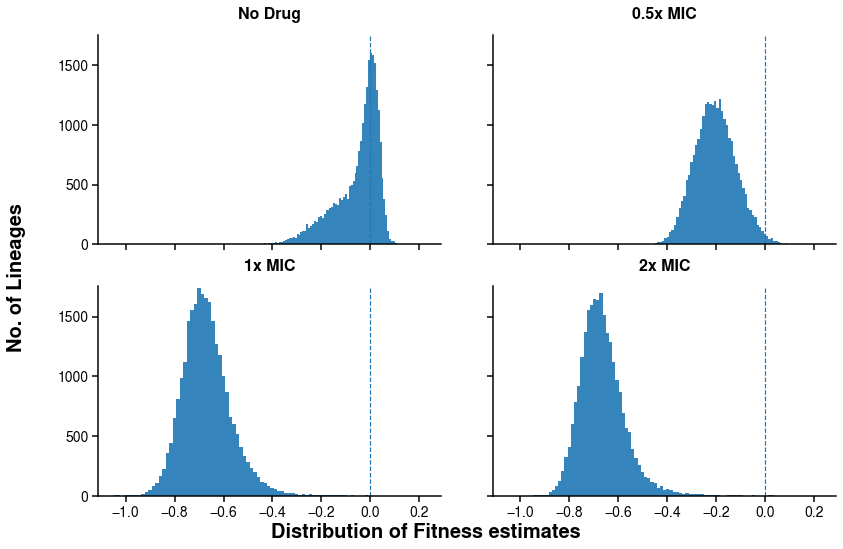

In [11]:
# ==========================================================
# Publication-format histogram of older C++ joint fitness
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# Global plot settings
# ----------------------------------------------------------
plt.rcParams.update({
    "font.family": "Nimbus Sans",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.5,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6
})

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
BASE_PATH = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/3_phenotype_inference/results/"
    "Joint_inference/Filtered/PUL"
)

conditions = {
    "No Drug": "CON",
    "0.5x MIC": "HMIC",
    "1x MIC": "FMIC",
    "2x MIC": "DMIC"
}

# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# ----------------------------------------------------------
# Plot histograms
# ----------------------------------------------------------
for ax, (title, con) in zip(axes, conditions.items()):

    file_path = (
        BASE_PATH /
        con /
        "fitness_ALLreps_with_ids.tsv"
    )

    df = pd.read_csv(
        file_path,
        sep="\t"
    )

    fitness = (
        pd.to_numeric(
            df["s"],
            errors="coerce"
        )
        .dropna()
    )

    ax.hist(
        fitness,
        bins=80,
        alpha=0.9,
        zorder=1
    )

    # Add headroom above bars
    ax.margins(y=0.01)

    # Zero fitness reference
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    # Subplot title (above plot, no overlap)
    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    # Cleaner spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------------------------------
# Shared labels
# ----------------------------------------------------------
fig.supxlabel(
    "Distribution of Fitness estimates",
    fontsize=20,
    fontweight="bold",
    y=0.04
)

fig.supylabel(
    "No. of Lineages",
    fontsize=20,
    fontweight="bold",
    x=0.015
)

# ----------------------------------------------------------
# Layout adjustments
# ----------------------------------------------------------
plt.tight_layout()

plt.subplots_adjust(
    left=0.12,
    bottom=0.12,
    top=0.92,
    wspace=0.15,
    hspace=0.20
)

# plt.savefig(
#     "PUL_joint_fitness_distribution_publication.pdf",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.savefig(
    "PUL_joint_fitness_distribution_publication.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

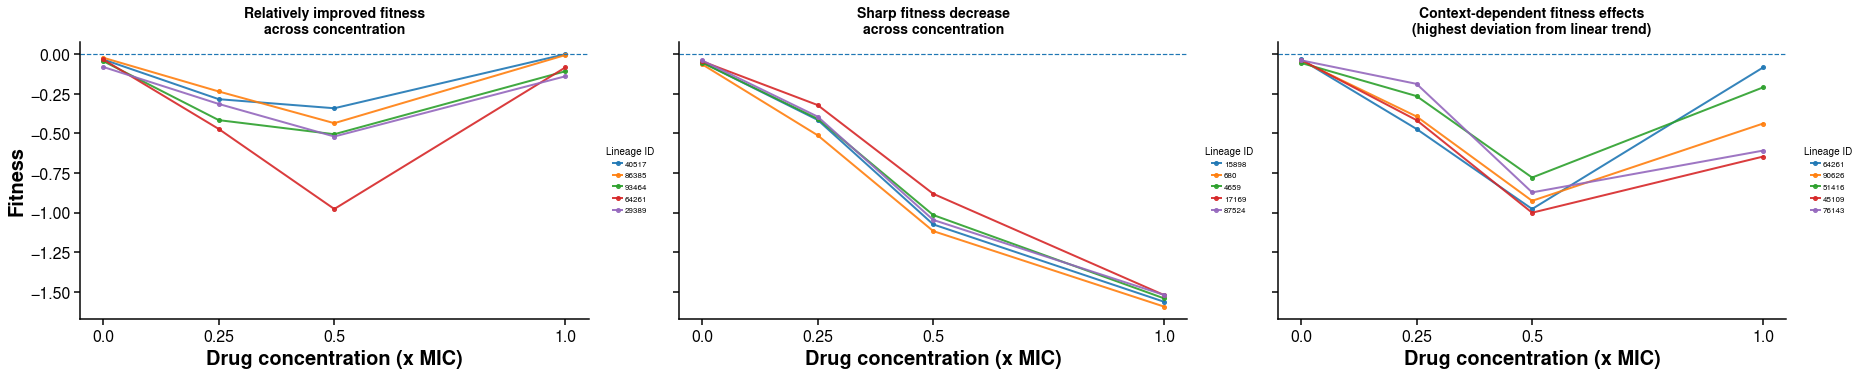

In [23]:
# ==========================================================
# Plot example lineage fitness trajectories across MIC levels
# Using older C++ joint fitness estimates
# Each subplot has its own lineage legend
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# Paths and condition metadata
# ----------------------------------------------------------
BASE_PATH = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/3_phenotype_inference/results/"
    "Joint_inference/Filtered/FLU"
)

condition_map = {
    "CON": 0.00,
    "QMIC": 0.25,
    "HMIC": 0.50,
    "FMIC": 1.00
}

# ----------------------------------------------------------
# Load and merge fitness estimates
# ----------------------------------------------------------
dfs = []

for con, mic in condition_map.items():

    file_path = (
        BASE_PATH /
        con /
        "fitness_ALLreps_with_ids.tsv"
    )

    df = pd.read_csv(
        file_path,
        sep="\t"
    )

    df = df[
        ["ID", "Lineage", "s"]
    ].copy()

    df["s"] = pd.to_numeric(
        df["s"],
        errors="coerce"
    )

    df = df.rename(
        columns={
            "s": f"fitness_{con}"
        }
    )

    dfs.append(df)

fitness_df = dfs[0]

for df in dfs[1:]:

    fitness_df = fitness_df.merge(
        df,
        on=["ID", "Lineage"],
        how="inner"
    )

fitness_cols = [
    "fitness_CON",
    "fitness_QMIC",
    "fitness_HMIC",
    "fitness_FMIC"
]

fitness_df = fitness_df.dropna(
    subset=fitness_cols
).copy()

# ----------------------------------------------------------
# Compute trajectory features
# ----------------------------------------------------------
x = np.array([
    0.00,
    0.25,
    0.50,
    1.00
])

Y = fitness_df[
    fitness_cols
].values

# Linear slope
slopes = np.array([
    np.polyfit(x, y, 1)[0]
    for y in Y
])

# Non-linearity score
pred = np.array([
    np.polyval(
        np.polyfit(x, y, 1),
        x
    )
    for y in Y
])

nonlinear_score = np.max(
    np.abs(Y - pred),
    axis=1
)

fitness_df["slope"] = slopes
fitness_df[
    "nonlinear_score"
] = nonlinear_score

# ----------------------------------------------------------
# Select lineages
# ----------------------------------------------------------
N_LINEAGES = 5

# Relatively improved fitness
improved = (
    fitness_df
    .sort_values(
        "slope",
        ascending=False
    )
    .head(N_LINEAGES)
)

# Sharp fitness decrease
sharp_decrease = (
    fitness_df
    .sort_values(
        "slope",
        ascending=True
    )
    .head(N_LINEAGES)
)

# Context-dependent effects
context_dependent = (
    fitness_df
    .sort_values(
        "nonlinear_score",
        ascending=False
    )
    .head(N_LINEAGES)
)

plot_sets = [
    (
        improved,
        "Relatively improved fitness\nacross concentration"
    ),
    (
        sharp_decrease,
        "Sharp fitness decrease\nacross concentration"
    ),
    (
        context_dependent,
        "Context-dependent fitness effects\n(highest deviation from linear trend)"
    )
]

# ----------------------------------------------------------
# Plot settings
# ----------------------------------------------------------
plt.rcParams.update({
    "font.family": "Nimbus Sans",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.5,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6
})

# ----------------------------------------------------------
# Generate plot
# ----------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(26, 5.5),
    sharey=True
)

for ax, (plot_df, title) in zip(
    axes,
    plot_sets
):

    for _, row in plot_df.iterrows():

        y = row[
            fitness_cols
        ].values.astype(float)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=4,
            alpha=0.9,
            label=str(row["ID"])
        )

    # Reference line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    # Title
    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # X label
    ax.set_xlabel(
        "Drug concentration (x MIC)",
        fontsize=20,
        fontweight="bold"
    )

    # X ticks
    ax.set_xticks([
        0,
        0.25,
        0.5,
        1.0
    ])

    ax.set_xticklabels([
        "0.0",
        "0.25",
        "0.5",
        "1.0"
    ])

    # Clean spines
    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    # --------------------------------------
    # Subplot-specific legend
    # --------------------------------------
    ax.legend(
        title="Lineage ID",
        fontsize=8,
        title_fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handlelength=1.2,
        handletextpad=0.3
    )

# ----------------------------------------------------------
# Shared Y label
# ----------------------------------------------------------
axes[0].set_ylabel(
    "Fitness",
    fontsize=20,
    fontweight="bold"
)

# ----------------------------------------------------------
# Save and show
# ----------------------------------------------------------
plt.tight_layout()

plt.savefig(
    "FLU_fitness_trajectories_across_fluconazole.png",
    dpi=300,
    bbox_inches="tight"
)

# plt.savefig(
#     "FLU_fitness_trajectories_across_fluconazole.pdf",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

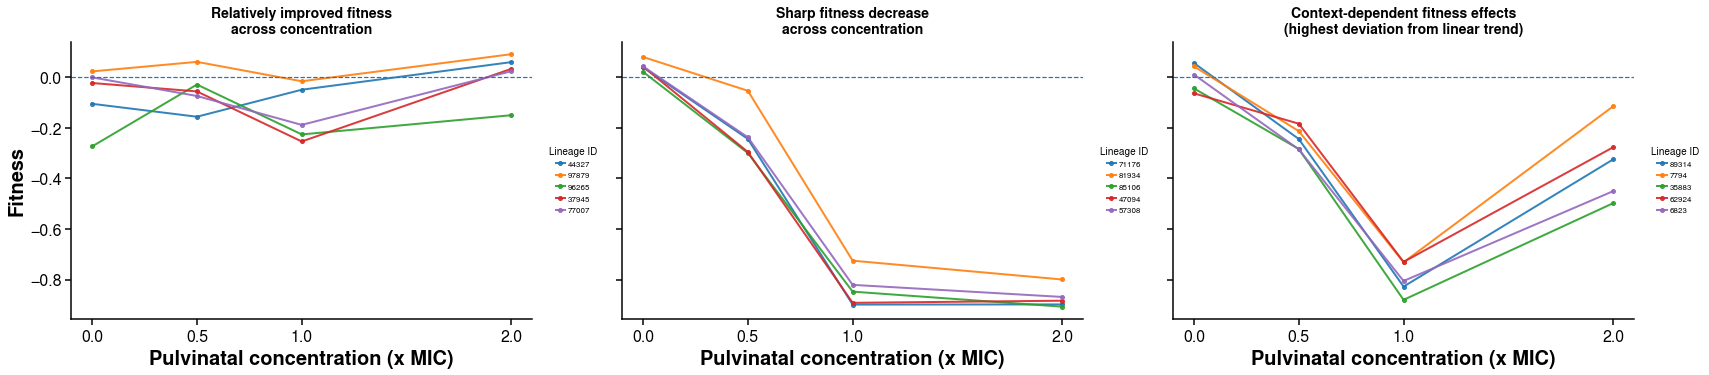

In [22]:
# ==========================================================
# Plot example lineage fitness trajectories across Pulvinatal levels
# Using older C++ joint fitness estimates
# Each subplot has its own lineage legend
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# Paths and condition metadata
# ----------------------------------------------------------
BASE_PATH = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/3_phenotype_inference/results/"
    "Joint_inference/Filtered/PUL"
)

condition_map = {
    "CON": 0.00,
    "HMIC": 0.50,
    "FMIC": 1.00,
    "DMIC": 2.00
}

# ----------------------------------------------------------
# Load and merge fitness estimates
# ----------------------------------------------------------
dfs = []

for con, conc in condition_map.items():

    file_path = (
        BASE_PATH /
        con /
        "fitness_ALLreps_with_ids.tsv"
    )

    df = pd.read_csv(
        file_path,
        sep="\t"
    )

    df = df[
        ["ID", "Lineage", "s"]
    ].copy()

    df["s"] = pd.to_numeric(
        df["s"],
        errors="coerce"
    )

    df = df.rename(
        columns={
            "s": f"fitness_{con}"
        }
    )

    dfs.append(df)

fitness_df = dfs[0]

for df in dfs[1:]:

    fitness_df = fitness_df.merge(
        df,
        on=["ID", "Lineage"],
        how="inner"
    )

fitness_cols = [
    "fitness_CON",
    "fitness_HMIC",
    "fitness_FMIC",
    "fitness_DMIC"
]

fitness_df = fitness_df.dropna(
    subset=fitness_cols
).copy()

# ----------------------------------------------------------
# Compute trajectory features
# ----------------------------------------------------------
x = np.array([
    0.00,
    0.50,
    1.00,
    2.00
])

Y = fitness_df[
    fitness_cols
].values

slopes = np.array([
    np.polyfit(x, y, 1)[0]
    for y in Y
])

pred = np.array([
    np.polyval(
        np.polyfit(x, y, 1),
        x
    )
    for y in Y
])

nonlinear_score = np.max(
    np.abs(Y - pred),
    axis=1
)

fitness_df["slope"] = slopes
fitness_df["nonlinear_score"] = nonlinear_score

# ----------------------------------------------------------
# Select example lineages for each panel
# ----------------------------------------------------------
N_LINEAGES = 5

improved = (
    fitness_df
    .sort_values(
        "slope",
        ascending=False
    )
    .head(N_LINEAGES)
)

sharp_decrease = (
    fitness_df
    .sort_values(
        "slope",
        ascending=True
    )
    .head(N_LINEAGES)
)

context_dependent = (
    fitness_df
    .sort_values(
        "nonlinear_score",
        ascending=False
    )
    .head(N_LINEAGES)
)

plot_sets = [
    (
        improved,
        "Relatively improved fitness\nacross concentration"
    ),
    (
        sharp_decrease,
        "Sharp fitness decrease\nacross concentration"
    ),
    (
        context_dependent,
        "Context-dependent fitness effects\n(highest deviation from linear trend)"
    )
]

# ----------------------------------------------------------
# Plot settings
# ----------------------------------------------------------
plt.rcParams.update({
    "font.family": "Nimbus Sans",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.5,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6
})

# ----------------------------------------------------------
# Generate plot
# ----------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 5.5),
    sharey=True
)

for ax, (plot_df, title) in zip(
    axes,
    plot_sets
):

    for _, row in plot_df.iterrows():

        y = row[
            fitness_cols
        ].values.astype(float)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=4,
            alpha=0.9,
            label=str(row["ID"])
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel(
        "Pulvinatal concentration (x MIC)",
        fontsize=20,
        fontweight="bold"
    )

    ax.set_xticks([
        0,
        0.5,
        1.0,
        2.0
    ])

    ax.set_xticklabels([
        "0.0",
        "0.5",
        "1.0",
        "2.0"
    ])

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.legend(
        title="Lineage ID",
        fontsize=8,
        title_fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handlelength=1.2,
        handletextpad=0.3
    )

axes[0].set_ylabel(
    "Fitness",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "PUL_fitness_trajectories_across_pulvinatal.png",
    dpi=300,
    bbox_inches="tight"
)

# plt.savefig(
#     "PUL_fitness_trajectories_across_pulvinatal.pdf",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()